In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. नकली डेटासेट बनाना
np.random.seed(42)
n_students = 500

data = {
    'Attendance_Percentage': np.random.randint(55, 100, n_students),
    'Previous_Exam_Score': np.random.randint(40, 100, n_students),
    'Study_Hours_Per_Week': np.random.randint(5, 35, n_students),
    'Assignment_Completion_Rate': np.random.randint(50, 100, n_students),
    'Participation_Score': np.random.randint(1, 10, n_students)
}

df = pd.DataFrame(data)

# रिस्क तय करने का नियम
def determine_risk(row):
    if row['Attendance_Percentage'] < 75 or row['Previous_Exam_Score'] < 50 or row['Study_Hours_Per_Week'] < 10:
        return 1  # Academic Risk
    else:
        return 0  # Safe

df['Academic_Risk'] = df.apply(determine_risk, axis=1)
print("--- Dataset Sample ---")
print(df.head())

--- Dataset Sample ---
   Attendance_Percentage  Previous_Exam_Score  Study_Hours_Per_Week  \
0                     93                   62                    29   
1                     83                   56                    21   
2                     69                   65                    11   
3                     97                   47                    26   
4                     62                   68                    30   

   Assignment_Completion_Rate  Participation_Score  Academic_Risk  
0                          54                    5              0  
1                          69                    5              0  
2                          60                    4              1  
3                          91                    6              1  
4                          51                    3              1  


In [2]:
# 2. मॉडल को ट्रेन करना
X = df.drop('Academic_Risk', axis=1)
y = df['Academic_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Project Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Project Model Accuracy: 100.00%


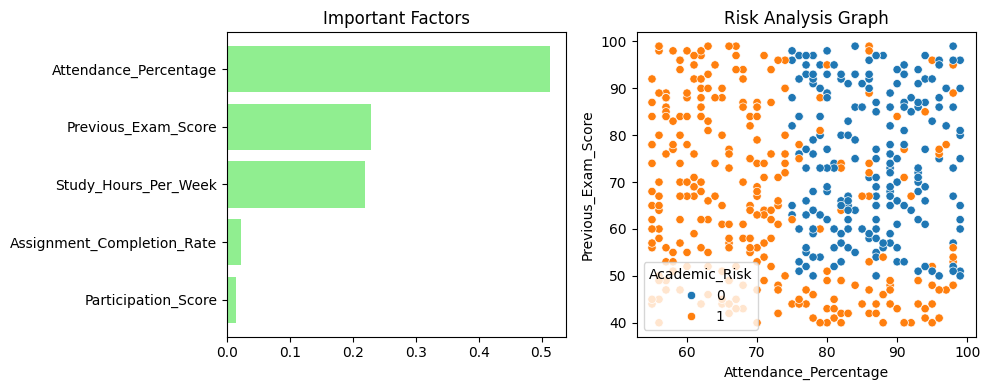

In [3]:
# 3. ग्राफ और विजुअलाइजेशन
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
importances = model.feature_importances_
indices = np.argsort(importances)
plt.title('Important Factors')
plt.barh(range(len(indices)), importances[indices], color='lightgreen')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Attendance_Percentage', y='Previous_Exam_Score', hue='Academic_Risk')
plt.title('Risk Analysis Graph')

plt.tight_layout()
plt.show()